## 混淆矩陣
預測結果有四種情況：  

              實際正(生病)  實際負(健康)  
預測正(生病)    TP            FP  
預測負(健康)    FN            TN  

TP = True Positive  = 預測生病，實際生病  ✅  
TN = True Negative  = 預測健康，實際健康  ✅  
FP = False Positive = 預測生病，實際健康  ❌  
FN = False Negative = 預測健康，實際生病  ❌  

# Precision（精確率）：  
  我預測是生病的人裡面  
  真的生病的比例  
  = TP / (TP + FP)  
  → 我說你生病，有多少機率是真的  

# Recall（召回率）：  
  所有真正生病的人裡面  
  我找到了幾個  
  = TP / (TP + FN)  
  → 生病的人我找到了幾個  

# F1
F1 = 2 × (Precision × Recall) / (Precision + Recall)  
兩個都高 → F1 高  
其中一個很低 → F1 被拉低  

#
分類：  
  平衡資料    → Accuracy  
  不平衡資料  → F1, AUC-ROC  
  醫療/詐欺   → Recall 優先  
  垃圾郵件    → Precision 優先  
  競賽        → AUC-ROC 最常見  

迴歸：  
  MSE   → 對大誤差敏感  
  RMSE  → 跟原始單位一樣，好解釋  
  MAE   → 對異常值不敏感  
  R²    → 解釋能力，0~1  

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

plt.rcParams['font.family'] = 'Microsoft JhengHei'
plt.rcParams['axes.unicode_minus'] = False

# 不平衡資料：90% 健康，10% 生病
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    weights=[0.9, 0.1],
    random_state=42
)

print(f"健康（0）: {sum(y==0)}")
print(f"生病（1）: {sum(y==1)}")

健康（0）: 897
生病（1）: 103


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")

Accuracy:  0.9400
Precision: 0.8824
Recall:    0.6000
F1:        0.7143


Accuracy 0.94 → 看起來很好  
但是：  
Recall 0.60 → 100個生病的人  
              只找到 60個  
              漏掉了 40個！  

醫療場景這40個人沒有得到治療  
Accuracy 高但模型其實很危險  

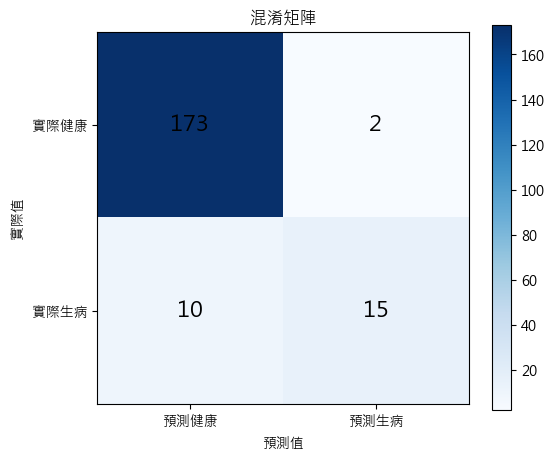

[[173   2]
 [ 10  15]]


In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title('混淆矩陣')
plt.xlabel('預測值')
plt.ylabel('實際值')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], 
                ha='center', va='center', 
                fontsize=16, color='black')

plt.xticks([0, 1], ['預測健康', '預測生病'])
plt.yticks([0, 1], ['實際健康', '實際生病'])
plt.show()

print(cm)

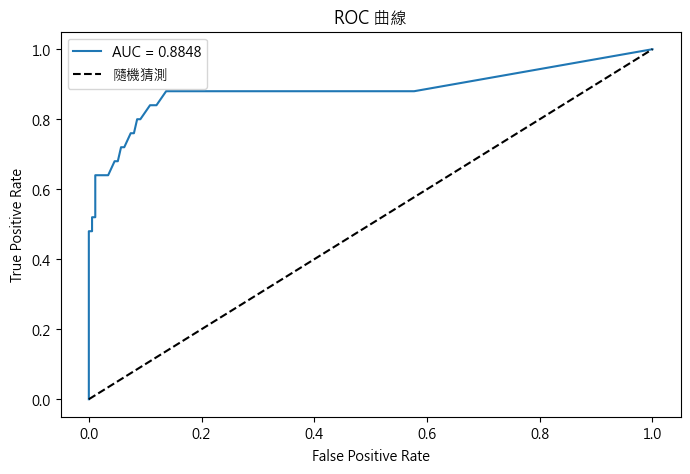

In [8]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='隨機猜測')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC 曲線')
plt.legend()
plt.show()

#  predict_proba()  
ROC / AUC / 調 threshold  
信心程度  

# fpr, tpr, _  
_ 忽略變數  
# y 軸：TPR（抓到正樣本比例）  
# x 軸：FPR（誤判負樣本為正）  

# FPR = 0.2

FPR = FP / N = 0.2

意思是：
所有負類裡，有 20% 被你誤判成正類

例如如果有 10 個負類：
→ FP = 0.2 × 10 = 2 個誤判

#  TPR = 0.9

TPR = TP / P = 0.9

意思是：
所有正類裡，有 90% 被你抓對

例如如果有 10 個正類：
→ TP = 9 個正確抓到
→ FN = 1 個漏掉

# AUC 0.88 
虛線是隨機猜測的基準線：  
如果模型完全隨機猜  
AUC = 0.5 → 就是那條虛線  

AUC = 1.0  → 完美模型  
AUC = 0.9+ → 非常好  
AUC = 0.8+ → 好  
AUC = 0.7+ → 普通  
AUC = 0.5  → 跟亂猜一樣  
AUC < 0.5  → 比亂猜還差  

Accuracy, F1 → 需要決定一個閾值（通常是0.5）  
               才能把機率變成 0 或 1  

AUC → 不需要閾值  
      直接評估模型的機率排序能力  
      對資料不平衡也不敏感  